In [1]:
# [CELL 1]
import simbench as sb
import pandapower as pp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings('ignore')

# 1. 获取网架
sb_code = "1-LV-rural1--0-sw"
print(f"正在加载 SimBench 官方网架: {sb_code} ...")
net = sb.get_simbench_net(sb_code)

print("\n" + "="*40)
print(" 🔌 网架物理元数据审查 (Topology Audit)")
print("="*40)
print(f"母线 (Buses) 节点总数 : {len(net['bus'])}")
print(f"物理线路 (Lines) 数量   : {len(net['line'])}")
print(f"负荷节点 (Loads) 数量   : {len(net['load'])}")
print(f"光伏电源 (Sgens) 数量   : {len(net['sgen'])}")
print(f"外电网/变压器接入点     : {len(net['ext_grid'])}")

# 我们将基于 Bus (母线) 级别来聚合状态，计算纯负荷与产消者
load_buses = set(net['load']['bus'].values)
sgen_buses = set(net['sgen']['bus'].values)

pure_loads = list(load_buses - sgen_buses)
prosumers = list(load_buses & sgen_buses)

print(f"\n👉 诊断结论：共有 {len(prosumers)} 个节点自带光伏与负荷 (Prosumers)。")
print(f"👉 你的 MADRL 环境最大可支持部署 {len(prosumers)} 个储能智能体 (Actors)！")

正在加载 SimBench 官方网架: 1-LV-rural1--0-sw ...

 🔌 网架物理元数据审查 (Topology Audit)
母线 (Buses) 节点总数 : 15
物理线路 (Lines) 数量   : 13
负荷节点 (Loads) 数量   : 13
光伏电源 (Sgens) 数量   : 4
外电网/变压器接入点     : 1

👉 诊断结论：共有 4 个节点自带光伏与负荷 (Prosumers)。
👉 你的 MADRL 环境最大可支持部署 4 个储能智能体 (Actors)！


2. 正在重新生成完美的树状辐射拓扑可视化...


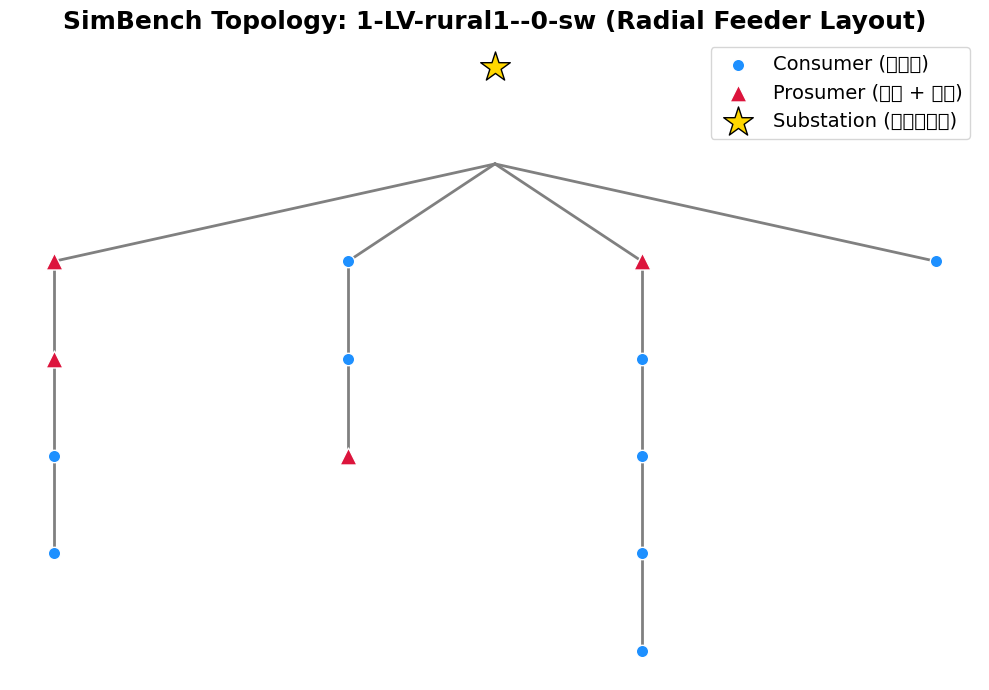

👉 导师提示：现在的拓扑图应该是一棵完美的『自上而下』的倒立树！变压器(黄星)在最上方作为根节点，向各个配电分支延伸，红色的产消者节点分布在最下方的枝叶上。


In [2]:
# [CELL 2]
import pandapower.topology as top
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

print("2. 正在重新生成完美的树状辐射拓扑可视化...")

# 【导师特供】：手写专为配电网设计的层级树状布局算法，彻底绕开底层库的 Bug
def generate_feeder_coordinates(net):
    mg = top.create_nxgraph(net)
    # 提取最小生成树，确保电网是严格的辐射状(无环网)
    tree = nx.minimum_spanning_tree(mg)
    # 找到外电网接入点（变压器）作为树根
    root_node = net['ext_grid']['bus'].values[0]

    def _hierarchy_pos(G, node, width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5, pos=None, parent=None):
        """递归分配树状节点的二维坐标"""
        if pos is None:
            pos = {node: (xcenter, vert_loc)}
        else:
            pos[node] = (xcenter, vert_loc)
        
        children = list(G.neighbors(node))
        if parent is not None and parent in children:
            children.remove(parent)
            
        if len(children) != 0:
            dx = width / len(children)
            nextx = xcenter - width/2 - dx/2
            for child in children:
                nextx += dx
                pos = _hierarchy_pos(G, child, width=dx, vert_gap=vert_gap, 
                                     vert_loc=vert_loc-vert_gap, xcenter=nextx,
                                     pos=pos, parent=node)
        return pos

    # 计算坐标并转为 DataFrame
    pos_dict = _hierarchy_pos(tree, root_node)
    return pd.DataFrame.from_dict(pos_dict, orient='index', columns=['x', 'y'])

# 直接使用我们的专有布局算法覆盖电网坐标
net['bus_geodata'] = generate_feeder_coordinates(net)

coords = net['bus_geodata'].copy()
lines = net['line'].copy()

plt.figure(figsize=(10, 7))

# 1. 画物理线路 (配电缆)
for idx, line in lines.iterrows():
    fb = line['from_bus']
    tb = line['to_bus']
    if fb in coords.index and tb in coords.index:
        plt.plot([coords.at[fb, 'x'], coords.at[tb, 'x']], 
                 [coords.at[fb, 'y'], coords.at[tb, 'y']], color='gray', linewidth=2, zorder=1)

# 2. 提取外电网（变电站）节点
ext_grids = list(net['ext_grid']['bus'].values)

# 3. 安全过滤各类节点 (基于上一个 Cell 的结果)
valid_pure_loads = [b for b in pure_loads if b in coords.index]
valid_prosumers = [b for b in prosumers if b in coords.index]
valid_ext_grids = [b for b in ext_grids if b in coords.index]

# 4. 绘制拓扑节点
if valid_pure_loads:
    plt.scatter(coords.loc[valid_pure_loads, 'x'], coords.loc[valid_pure_loads, 'y'], 
                c='dodgerblue', s=80, edgecolors='white', label='Consumer (仅负荷)', zorder=3)

if valid_prosumers:
    plt.scatter(coords.loc[valid_prosumers, 'x'], coords.loc[valid_prosumers, 'y'], 
                c='crimson', s=150, marker='^', edgecolors='white', label='Prosumer (负荷 + 光伏)', zorder=4)

if valid_ext_grids:
    plt.scatter(coords.loc[valid_ext_grids, 'x'], coords.loc[valid_ext_grids, 'y'], 
                c='gold', edgecolors='black', s=500, marker='*', label='Substation (配电变压器)', zorder=5)

plt.title(f"SimBench Topology: {sb_code} (Radial Feeder Layout)", fontsize=18, fontweight='bold')
plt.legend(fontsize=14, loc='upper right')
plt.axis('off') # 隐藏坐标轴
plt.tight_layout()
plt.show()

print("👉 导师提示：现在的拓扑图应该是一棵完美的『自上而下』的倒立树！变压器(黄星)在最上方作为根节点，向各个配电分支延伸，红色的产消者节点分布在最下方的枝叶上。")

In [3]:
# [CELL 3]
LOAD_PROFILE_SUFFIX = "_pload"
STEPS_PER_DAY = 96

load_profile_table = net["profiles"]["load"].copy()
renewable_profile_table = net["profiles"]["renewables"].copy()
profile_time = pd.to_datetime(load_profile_table["time"], format="%d.%m.%Y %H:%M")

load_profile_columns = [col for col in load_profile_table.columns if col.endswith(LOAD_PROFILE_SUFFIX)]
renewable_profile_columns = [col for col in renewable_profile_table.columns if col != "time"]

if not load_profile_columns:
    raise ValueError("No active load profile columns were found in net['profiles']['load'].")
if not renewable_profile_columns:
    raise ValueError("No renewable profile columns were found in net['profiles']['renewables'].")

load_profile_arrays = {
    col: load_profile_table[col].to_numpy(dtype=np.float32, copy=True)
    for col in load_profile_columns
}
renewable_profile_arrays = {
    col: renewable_profile_table[col].to_numpy(dtype=np.float32, copy=True)
    for col in renewable_profile_columns
}

n_steps = len(profile_time)
bus_ids = sorted(
    set(net["load"]["bus"].astype(int).tolist())
    | set(net["sgen"]["bus"].astype(int).tolist())
)
load_bus_arrays = {f"load_bus_{bus_id}": np.zeros(n_steps, dtype=np.float32) for bus_id in bus_ids}
pv_bus_arrays = {f"pv_bus_{bus_id}": np.zeros(n_steps, dtype=np.float32) for bus_id in bus_ids}

load_fallback_column = load_profile_columns[0]
renewable_fallback_column = renewable_profile_columns[0]
load_fallbacks = []
renewable_fallbacks = []

def resolve_profile_column(profile_name, available_arrays, fallback_column, suffix=""):
    raw_name = "" if pd.isna(profile_name) else str(profile_name).strip()
    candidate = f"{raw_name}{suffix}" if raw_name else ""
    if candidate and candidate in available_arrays:
        return candidate, False
    return fallback_column, True

for row in net["load"][["bus", "p_mw", "profile"]].itertuples(index=False):
    profile_column, used_fallback = resolve_profile_column(
        row.profile,
        load_profile_arrays,
        load_fallback_column,
        suffix=LOAD_PROFILE_SUFFIX,
    )
    if used_fallback:
        load_fallbacks.append((int(row.bus), row.profile, profile_column))

    load_bus_arrays[f"load_bus_{int(row.bus)}"] += (
        load_profile_arrays[profile_column] * (float(row.p_mw) * 1000.0)
    ).astype(np.float32, copy=False)

for row in net["sgen"][["bus", "p_mw", "profile"]].itertuples(index=False):
    profile_column, used_fallback = resolve_profile_column(
        row.profile,
        renewable_profile_arrays,
        renewable_fallback_column,
    )
    if used_fallback:
        renewable_fallbacks.append((int(row.bus), row.profile, profile_column))

    pv_bus_arrays[f"pv_bus_{int(row.bus)}"] += (
        renewable_profile_arrays[profile_column] * (float(row.p_mw) * 1000.0)
    ).astype(np.float32, copy=False)

load_columns = [f"load_bus_{bus_id}" for bus_id in bus_ids]
pv_columns = [f"pv_bus_{bus_id}" for bus_id in bus_ids]
load_matrix = np.column_stack([load_bus_arrays[col] for col in load_columns]).astype(np.float32, copy=False)
pv_matrix = np.column_stack([pv_bus_arrays[col] for col in pv_columns]).astype(np.float32, copy=False)

simbench_frame_dict = {"timestamp": profile_time}
simbench_frame_dict.update(load_bus_arrays)
simbench_frame_dict.update(pv_bus_arrays)
simbench_absolute_df = pd.DataFrame(simbench_frame_dict)
simbench_absolute_df["total_load_kw"] = load_matrix.sum(axis=1, dtype=np.float32)
simbench_absolute_df["total_pv_kw"] = pv_matrix.sum(axis=1, dtype=np.float32)

print("Absolute SimBench matrix created.")
print(f"  Shape           : {simbench_absolute_df.shape}")
print(f"  Load matrix     : {load_matrix.shape}")
print(f"  PV matrix       : {pv_matrix.shape}")
print(f"  Load fallback   : {len(load_fallbacks)}")
print(f"  PV fallback     : {len(renewable_fallbacks)}")
if load_fallbacks:
    print("  Sample load fallback:", load_fallbacks[:3])
if renewable_fallbacks:
    print("  Sample PV fallback:", renewable_fallbacks[:3])

display(simbench_absolute_df.head())


Absolute SimBench matrix created.
  Shape           : (35136, 29)
  Load matrix     : (35136, 13)
  PV matrix       : (35136, 13)
  Load fallback   : 0
  PV fallback     : 0


,timestamp,load_bus_0,load_bus_1,load_bus_2,load_bus_4,load_bus_5,load_bus_6,load_bus_7,load_bus_8,load_bus_9,...,pv_bus_6,pv_bus_7,pv_bus_8,pv_bus_9,pv_bus_10,pv_bus_11,pv_bus_12,pv_bus_13,total_load_kw,total_pv_kw
0,2016-01-01 00:00:00,4.494742,0.576924,1.153848,4.494742,0.432693,0.963159,0.711246,1.284212,1.926318,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.174833,0.0
1,2016-01-01 00:15:00,4.445616,1.666512,3.333024,4.445616,1.249884,0.952632,0.200607,1.270176,1.905264,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.064983,0.0
2,2016-01-01 00:30:00,5.845616,1.673544,3.347088,5.845616,1.255158,1.252632,0.191490,1.670176,2.505264,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.448204,0.0
3,2016-01-01 00:45:00,5.231576,1.923076,3.846152,5.231576,1.442307,1.121052,0.196050,1.494736,2.242104,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.384209,0.0
4,2016-01-01 01:00:00,5.747364,1.818948,3.637896,5.747364,1.364211,1.231578,0.227964,1.642104,2.463156,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.096313,0.0


In [4]:
# [CELL 4]
STEPS_PER_WEEK = 7 * STEPS_PER_DAY
WARMUP_STEPS = STEPS_PER_DAY

leap_day_mask = (simbench_absolute_df["timestamp"].dt.month == 2) & (simbench_absolute_df["timestamp"].dt.day == 29)
simbench_calendar_df = simbench_absolute_df.loc[~leap_day_mask].reset_index(drop=True).copy()
print(f"After removing leap day rows: {simbench_calendar_df.shape}")

remainder_steps = len(simbench_calendar_df) % STEPS_PER_WEEK
if remainder_steps:
    print(
        f"Dropping trailing remainder of {remainder_steps} steps to keep exactly "
        f"{len(simbench_calendar_df) // STEPS_PER_WEEK} full weeks."
    )
    simbench_calendar_df = simbench_calendar_df.iloc[:-remainder_steps].reset_index(drop=True).copy()

simbench_calendar_df["week_id"] = (
    np.arange(len(simbench_calendar_df), dtype=np.int32) // STEPS_PER_WEEK
).astype(np.int16)

weekly_summary = simbench_calendar_df.groupby("week_id", sort=True).agg(
    total_load_kw=("total_load_kw", "sum"),
    total_pv_kw=("total_pv_kw", "sum"),
)
max_pv_week = int(weekly_summary["total_pv_kw"].idxmax())
max_load_week = int(weekly_summary["total_load_kw"].idxmax())

selected_test_weeks = [max_pv_week]
if max_load_week not in selected_test_weeks:
    selected_test_weeks.append(max_load_week)
else:
    alternate_load_week = int(
        weekly_summary.loc[weekly_summary.index != max_pv_week, "total_load_kw"].idxmax()
    )
    selected_test_weeks.append(alternate_load_week)

remaining_weeks = [week for week in weekly_summary.index.tolist() if week not in selected_test_weeks]
extra_positions = np.linspace(0, len(remaining_weeks) - 1, num=4, dtype=int)[1:3]
extra_weeks = [int(remaining_weeks[pos]) for pos in extra_positions]
for week in extra_weeks:
    if week not in selected_test_weeks:
        selected_test_weeks.append(week)
selected_test_weeks = sorted(selected_test_weeks[:4])

selected_test_week_set = set(selected_test_weeks)
simbench_train_df = simbench_calendar_df.loc[
    ~simbench_calendar_df["week_id"].isin(selected_test_week_set)
].copy()
simbench_train_df["is_warmup"] = False

test_segments = []
test_segment_lengths = {}
skipped_warmup_weeks = []
expected_step = pd.Timedelta(minutes=15)

for week_id in selected_test_weeks:
    week_rows = simbench_calendar_df.loc[simbench_calendar_df["week_id"] == week_id].copy()
    if week_rows.empty:
        continue

    week_rows["week_id"] = int(week_id)
    week_rows["is_warmup"] = False
    segment_frames = []

    week_start_idx = int(week_rows.index.min())
    if week_start_idx >= WARMUP_STEPS:
        warmup_rows = simbench_calendar_df.iloc[week_start_idx - WARMUP_STEPS : week_start_idx].copy()
        warmup_rows["week_id"] = int(week_id)
        warmup_rows["is_warmup"] = True
        segment_frames.append(warmup_rows)
    else:
        skipped_warmup_weeks.append(int(week_id))
        print(f"Week {week_id} starts at the beginning of the calendar. Warm-up buffer skipped.")

    segment_frames.append(week_rows)
    segment_df = pd.concat(segment_frames, ignore_index=True)

    if len(segment_df) > 1:
        deltas = segment_df["timestamp"].diff().dropna()
        if not bool((deltas == expected_step).all()):
            raise ValueError(f"Timestamp continuity check failed for week {week_id}.")

    test_segments.append(segment_df)
    test_segment_lengths[int(week_id)] = int(len(segment_df))

if not test_segments:
    raise ValueError("No test segments were created from selected_test_weeks.")

simbench_test_df = pd.concat(test_segments, ignore_index=True)
simbench_test_df["is_warmup"] = simbench_test_df["is_warmup"].astype(bool)
simbench_train_df["is_warmup"] = simbench_train_df["is_warmup"].astype(bool)

expected_test_rows = sum(test_segment_lengths.values())
full_buffer_test_rows = len(selected_test_weeks) * (STEPS_PER_WEEK + WARMUP_STEPS)

print("Extreme Weeks")
print(f"  Max PV Week        : {max_pv_week}")
print(f"  Max Load Week      : {max_load_week}")
print(f"  Test Weeks         : {selected_test_weeks}")
print(f"  Warm-up steps      : {WARMUP_STEPS}")
print(f"  Test segment sizes : {test_segment_lengths}")
print(f"  Weekly summary     : {weekly_summary.shape}")
print(f"  Train shape        : {simbench_train_df.shape}")
print(f"  Test shape         : {simbench_test_df.shape}")
print(f"  Full-buffer target : {full_buffer_test_rows}")
print(f"  Actual test rows   : {expected_test_rows}")
if skipped_warmup_weeks:
    print(f"  Warm-up skipped for: {skipped_warmup_weeks}")

display(weekly_summary.loc[selected_test_weeks])


After removing leap day rows: (35040, 29)
Dropping trailing remainder of 96 steps to keep exactly 52 full weeks.
Extreme Weeks
  Max PV Week        : 20
  Max Load Week      : 41
  Test Weeks         : [16, 20, 33, 41]
  Warm-up steps      : 96
  Test segment sizes : {16: 768, 20: 768, 33: 768, 41: 768}
  Weekly summary     : (52, 2)
  Train shape        : (32256, 31)
  Test shape         : (3072, 31)
  Full-buffer target : 3072
  Actual test rows   : 3072


,total_load_kw,total_pv_kw
week_id,,
16,15496.557617,11446.782227
20,17167.240234,16758.375000
33,13854.447266,9976.802734
41,17866.580078,6450.910645


In [5]:
# [CELL 6]
from pathlib import Path

pv_columns = [col for col in simbench_calendar_df.columns if col.startswith("pv_bus_")]
load_columns = [col for col in simbench_calendar_df.columns if col.startswith("load_bus_")]
pv_columns.sort(key=lambda name: int(name.rsplit("_", 1)[-1]))
load_columns.sort(key=lambda name: int(name.rsplit("_", 1)[-1]))
active_pv_columns = [
    col for col in pv_columns
    if not np.allclose(simbench_calendar_df[col].to_numpy(dtype=np.float32), 0.0)
]
removed_pv_columns = [col for col in pv_columns if col not in active_pv_columns]

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "configs").exists():
    project_root = project_root.parent
if not (project_root / "configs").exists():
    raise RuntimeError("Could not locate the project root for CSV export.")

output_dir = project_root / "data"
output_dir.mkdir(parents=True, exist_ok=True)
train_path = output_dir / "simbench_train.csv"
test_path = output_dir / "simbench_test.csv"

export_columns = ["timestamp", "week_id", "is_warmup"] + load_columns + active_pv_columns
simbench_train_export = simbench_train_df.loc[:, export_columns].copy()
simbench_test_export = simbench_test_df.loc[:, export_columns].copy()

simbench_train_export.to_csv(train_path, index=False)
simbench_test_export.to_csv(test_path, index=False)

expected_test_rows = len(selected_test_weeks) * (STEPS_PER_WEEK + WARMUP_STEPS)
print(f"Dropped zero-only PV columns: {len(removed_pv_columns)}")
if removed_pv_columns:
    print("  Removed PV columns:", removed_pv_columns[:10])
print(f"Train export shape      : {simbench_train_export.shape}")
print(f"Test export shape       : {simbench_test_export.shape}")
print(f"Expected test rows      : {expected_test_rows}")
print(f"Actual test rows        : {len(simbench_test_export)}")
print(f"Saved train CSV to      : {train_path}")
print(f"Saved test CSV to       : {test_path}")

display(simbench_test_export.head(WARMUP_STEPS + 4))


Dropped zero-only PV columns: 9
  Removed PV columns: ['pv_bus_0', 'pv_bus_1', 'pv_bus_2', 'pv_bus_4', 'pv_bus_5', 'pv_bus_8', 'pv_bus_9', 'pv_bus_11', 'pv_bus_13']
Train export shape      : (32256, 20)
Test export shape       : (3072, 20)
Expected test rows      : 3072
Actual test rows        : 3072
Saved train CSV to      : C:\Users\10856\Desktop\GithubProject\MADRL_ESS\data\simbench_train.csv
Saved test CSV to       : C:\Users\10856\Desktop\GithubProject\MADRL_ESS\data\simbench_test.csv


,timestamp,week_id,is_warmup,load_bus_0,load_bus_1,load_bus_2,load_bus_4,load_bus_5,load_bus_6,load_bus_7,load_bus_8,load_bus_9,load_bus_10,load_bus_11,load_bus_12,load_bus_13,pv_bus_6,pv_bus_7,pv_bus_10,pv_bus_12
0,2016-04-22 01:00:00,16,True,2.235086,0.907600,1.815200,2.235086,0.680700,0.478947,0.332826,0.638596,0.957894,0.084270,2.722800,0.173670,1.134500,0.0,0.0,0.0,0.0
1,2016-04-22 01:15:00,16,True,2.591722,0.822232,1.644464,2.591722,0.616674,0.555369,0.373860,0.740492,1.110738,0.058988,2.466696,0.162464,1.027790,0.0,0.0,0.0,0.0
2,2016-04-22 01:30:00,16,True,1.891232,0.823172,1.646344,1.891232,0.617379,0.405264,0.341946,0.540352,0.810528,0.053370,2.469516,0.126050,1.028965,0.0,0.0,0.0,0.0
3,2016-04-22 01:45:00,16,True,2.395232,0.844276,1.688552,2.395232,0.633207,0.513264,0.328266,0.684352,1.026528,0.050562,2.532828,0.196078,1.055345,0.0,0.0,0.0,0.0
4,2016-04-22 02:00:00,16,True,2.210530,0.839588,1.679176,2.210530,0.629691,0.473685,0.537993,0.631580,0.947370,0.053370,2.518764,0.151260,1.049485,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2016-04-23 00:45:00,16,True,2.419788,0.930112,1.860224,2.419788,0.697584,0.518526,0.378420,0.691368,1.037052,0.106742,2.790336,0.226890,1.162640,0.0,0.0,0.0,0.0
96,2016-04-23 01:00:00,16,False,2.100490,0.926360,1.852720,2.100490,0.694770,0.450105,0.414894,0.600140,0.900210,0.109550,2.779080,0.232492,1.157950,0.0,0.0,0.0,0.0
97,2016-04-23 01:15:00,16,False,2.259656,0.916980,1.833960,2.259656,0.687735,0.484212,0.469605,0.645616,0.968424,0.067416,2.750940,0.103642,1.146225,0.0,0.0,0.0,0.0
98,2016-04-23 01:30:00,16,False,2.357894,0.872420,1.744840,2.357894,0.654315,0.505263,0.396657,0.673684,1.010526,0.087078,2.617260,0.176470,1.090525,0.0,0.0,0.0,0.0
